# **Diabetes Risk Prediction using Machine Learning**

Data:NHANES(National Health and Nutrition Examination Survey) from 2009-2019

Commonly Used NHANES Data Categories:
* Demographics and SDoH (age, gender, race/ethnicity, income, education)
* Dietary Data (24-hour dietary recall, food frequency)
* Physical Examination Data (body measurements, blood pressure, bone density)
* Laboratory Data (blood, urine, biomarkers)
* Medical Conditions (conditions like diabetes, cardiovascular disease)
* Lifestyle factors (smoking, drinking, exercising, etc.)
* Prescription Drug Use
Mental Health and Cognitive Function
* Environmental Exposures (e.g., lead, mercury, pesticides)

For project purpose, we selected the following categories:
* Demographics and SDoH
* Laboratory Data
* Medical Conditions
* Lifestyle Factors


## Define the Problem

Use supervised learning to predict whether the patient has/at risk of diabetes.

Lable: 1/0 whether patient has diabetes.

## Collect Data

Collected data on the following dimensions:
* Demographics and SDoH
* Laboratory Data
* Medical Conditions
* Lifestyle Factors


## Data Pre-processing





In [ ]:
%%bigquery diabetes
SELECT * FROM Diabetes.NHANES_Data limit 20

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
diabetes.head()

,id,RIAGENDR,RIDAGEYR,RIDRETH3,INDFMIN2,BMXBMI,LBXGH,LBDGLUSI,ALQ121,SMQ020,...,PAQ665,BPQ020,BPQ080,MCQ160C,MCQ160E,MCQ160F,MCQ160M,MCQ160L,KIQ022,DIQ010
0,55195,Female,1,Hispanic,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
1,61502,Female,1,Hispanic,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
2,66379,Female,1,Hispanic,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
3,70242,Male,1,Black,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
4,89046,Female,1,Black,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False


In [ ]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        20 non-null     Int64  
 1   RIAGENDR  20 non-null     object 
 2   RIDAGEYR  20 non-null     Int64  
 3   RIDRETH3  20 non-null     object 
 4   INDFMIN2  20 non-null     object 
 5   BMXBMI    20 non-null     object 
 6   LBXGH     20 non-null     object 
 7   LBDGLUSI  20 non-null     object 
 8   ALQ121    20 non-null     object 
 9   SMQ020    20 non-null     object 
 10  PAQ650    20 non-null     object 
 11  PAQ665    20 non-null     object 
 12  BPQ020    20 non-null     object 
 13  BPQ080    20 non-null     object 
 14  MCQ160C   20 non-null     object 
 15  MCQ160E   20 non-null     object 
 16  MCQ160F   20 non-null     object 
 17  MCQ160M   20 non-null     object 
 18  MCQ160L   20 non-null     object 
 19  KIQ022    20 non-null     object 
 20  DIQ010    20 non-null     boolean


In [ ]:
diabetes.head(10)

,id,RIAGENDR,RIDAGEYR,RIDRETH3,INDFMIN2,BMXBMI,LBXGH,LBDGLUSI,ALQ121,SMQ020,...,PAQ665,BPQ020,BPQ080,MCQ160C,MCQ160E,MCQ160F,MCQ160M,MCQ160L,KIQ022,DIQ010
0,55195,Female,1,Hispanic,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
1,61502,Female,1,Hispanic,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
2,66379,Female,1,Hispanic,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
3,70242,Male,1,Black,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
4,89046,Female,1,Black,10000-20000,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
5,58807,Female,2,Hispanic,10000-20000,15.61,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
6,84261,Male,2,White,10000-20000,16.6,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
7,86431,Female,2,Black,10000-20000,16.3,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
8,100121,Female,2,Hispanic,10000-20000,17.2,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False
9,69482,Female,3,Hispanic,10000-20000,16,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,False


TODO & DEMO: Change 'NA' to Null values for easier analysis.

In [ ]:
%%bigquery
DROP TABLE IF EXISTS Diabetes.nhanes_data_temp;
CREATE TABLE IF NOT EXISTS Diabetes.nhanes_data_temp AS (
SELECT id,
       RIAGENDR,
       RIDAGEYR,
       RIDRETH3,
       INDFMIN2,
       NULLIF(BMXBMI, 'NA') AS BMXBMI,
       NULLIF(LBXGH, 'NA') AS LBXGH,
       NULLIF(LBDGLUSI, 'NA') AS LBDGLUSI,
       NULLIF(ALQ121, 'NA') AS ALQ121,
       NULLIF(SMQ020, 'NA') AS SMQ020,
       NULLIF(PAQ650, 'NA') AS PAQ650,
       NULLIF(PAQ665, 'NA') AS PAQ665,
       NULLIF(BPQ020, 'NA') AS BPQ020,
       NULLIF(BPQ080, 'NA') AS BPQ080,
       NULLIF(MCQ160C, 'NA') AS MCQ160C,
       NULLIF(MCQ160E, 'NA') AS MCQ160E,
       NULLIF(MCQ160F, 'NA') AS MCQ160F,
       NULLIF(MCQ160M, 'NA') AS MCQ160M,
       NULLIF(MCQ160L, 'NA') AS MCQ160L,
       NULLIF(KIQ022, 'NA') AS KIQ022,
       DIQ010
FROM
  Diabetes.NHANES_Data)

Query is running:   0%|          |

""


In [ ]:
%%bigquery data_temp
SELECT * FROM Diabetes.nhanes_data_temp

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
data_temp.head()

,id,RIAGENDR,RIDAGEYR,RIDRETH3,INDFMIN2,BMXBMI,LBXGH,LBDGLUSI,ALQ121,SMQ020,...,PAQ665,BPQ020,BPQ080,MCQ160C,MCQ160E,MCQ160F,MCQ160M,MCQ160L,KIQ022,DIQ010
0,53752,Male,1,Hispanic,10000-20000,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,False
1,73575,Male,1,Black,10000-20000,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,False
2,87254,Male,1,Other,10000-20000,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,False
3,87469,Male,1,Hispanic,10000-20000,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,False
4,96454,Male,1,Other,10000-20000,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,False


TODO & DEMO: change column names according to data dictionary.

In [ ]:
%%bigquery
DROP TABLE IF EXISTS Diabetes.nhanes_data_cleaned;
CREATE TABLE IF NOT EXISTS Diabetes.nhanes_data_cleaned AS (
SELECT
    id,
    RIAGENDR AS gender,
    RIDAGEYR AS age,
    RIDRETH3 AS race,
    INDFMIN2 AS family_income,
    BMXBMI AS bmi,
    LBXGH AS a1c_lvl,
    LBDGLUSI AS fasting_glucose_lvl,
    ALQ121 AS regular_drinker,
    SMQ020 AS regular_smoker,
    PAQ650 AS vigorous_exerciser,
    PAQ665 AS moderate_exerciser,
    BPQ020 AS high_blood_pressure,
    BPQ080 AS high_cholestrol_lvl,
    MCQ160C AS coronory_heart_disease,
    MCQ160E AS heart_attack,
    MCQ160F AS stroke,
    MCQ160M AS thyroid_issue,
    MCQ160L AS liver_issue,
    KIQ022 AS kidney_issue,
    DIQ010 AS diabetes
  FROM
    Diabetes.nhanes_data_temp)

Query is running:   0%|          |

""


In [ ]:
%%bigquery diabetes
select * from diabetes.nhanes_data_cleaned

Executing query with job ID: d750f37b-e3b2-41d0-9839-4e2762ac09a0
Query executing: 0.29s


ERROR:
 404 Not found: Dataset norse-lens-455820-c2:diabetes was not found in location US; reason: notFound, message: Not found: Dataset norse-lens-455820-c2:diabetes was not found in location US

Location: US
Job ID: d750f37b-e3b2-41d0-9839-4e2762ac09a0



In [ ]:
%%bigquery
DROP TABLE IF EXISTS Diabetes.nhanes_data_clean;
CREATE TABLE IF NOT EXISTS Diabetes.nhanes_data_clean AS (
SELECT
    CAST(id AS STRING) AS id,
    gender,
    age,
    race,
    family_income,
    CAST(bmi AS FLOAT64) AS bmi,
    CAST(a1c_lvl AS FLOAT64) AS a1c_lvl,
    CAST(fasting_glucose_lvl AS FLOAT64) AS fasting_glucose_lvl,
    CASE WHEN regular_drinker = 'yes' THEN 1
         WHEN regular_drinker = 'no' THEN 0
         ELSE NULL END AS regular_drinker,
    CASE WHEN regular_smoker = 'yes' THEN 1
     WHEN regular_smoker = 'no' THEN 0
     ELSE NULL END AS regular_smoker,
    CASE WHEN vigorous_exerciser = 'yes' THEN 1
     WHEN vigorous_exerciser = 'no' THEN 0
     ELSE NULL END AS vigorous_exerciser,
    CASE WHEN moderate_exerciser = 'yes' THEN 1
     WHEN moderate_exerciser = 'no' THEN 0
     ELSE NULL END AS moderate_exerciser,
    CASE WHEN high_blood_pressure = 'yes' THEN 1
     WHEN high_blood_pressure = 'no' THEN 0
     ELSE NULL END AS high_blood_pressure,
    CASE WHEN high_cholestrol_lvl = 'yes' THEN 1
        WHEN high_cholestrol_lvl = 'no' THEN 0
        ELSE NULL END AS high_cholestrol_lvl,
    CASE WHEN coronory_heart_disease = 'yes' THEN 1
        WHEN coronory_heart_disease = 'no' THEN 0
        ELSE NULL END AS coronory_heart_disease,
    CASE WHEN heart_attack = 'yes' THEN 1
        WHEN heart_attack = 'no' THEN 0
        ELSE NULL END AS heart_attack,
    CASE WHEN stroke = 'yes' THEN 1
        WHEN stroke = 'no' THEN 0
        ELSE NULL END AS stroke,
    CASE WHEN thyroid_issue = 'yes' THEN 1
        WHEN thyroid_issue = 'no' THEN 0
        ELSE NULL END AS thyroid_issue,
    CASE WHEN liver_issue = 'yes' THEN 1
        WHEN liver_issue = 'no' THEN 0
        ELSE NULL END AS liver_issue,
    CASE WHEN kidney_issue = 'yes' THEN 1
        WHEN kidney_issue = 'no' THEN 0
        ELSE NULL END AS kidney_issue,
    CASE WHEN diabetes = True THEN 1
        WHEN diabetes = False THEN 0
     ELSE NULL END AS diabetes
  FROM
    Diabetes.nhanes_data_cleaned)

Query is running:   0%|          |

""


In [ ]:
%%bigquery diabetes
SELECT *
FROM
Diabetes.nhanes_data_clean

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
diabetes.isnull().sum(axis = 0)/46912

,0
id,0.000000
gender,0.000000
age,0.000000
race,0.000000
family_income,0.000000
bmi,0.081941
a1c_lvl,0.331408
fasting_glucose_lvl,0.677993
regular_drinker,0.471308
regular_smoker,0.382226


**TODO: Handle Missingness**
:
Use Bigquery SQL
* Drop columns with > 50% missingness
* Use median for numerical variables
* Use mode for categorical variables + add additional column as a indicator variable for missingness.

In [ ]:
# Calculate missing percentage for each column
missing_percentage = diabetes.isnull().mean()

# Filter columns that have <= 50% missingness
columns_to_keep = missing_percentage[missing_percentage <= 0.5].index.tolist()

# Drop columns with > 50% missingness
df_cleaned = diabetes[columns_to_keep].copy()

In [ ]:
df_cleaned.columns

Index(['id', 'gender', 'age', 'race', 'family_income', 'bmi', 'a1c_lvl',
       'regular_drinker', 'regular_smoker', 'vigorous_exerciser',
       'moderate_exerciser', 'high_blood_pressure', 'high_cholestrol_lvl',
       'coronory_heart_disease', 'heart_attack', 'stroke', 'thyroid_issue',
       'liver_issue', 'kidney_issue', 'diabetes'],
      dtype='object')

In [ ]:
# Identify numerical columns
numerical_columns = [ 'age',  'bmi', 'a1c_lvl']

# Impute missing numerical columns with the median
for col in numerical_columns:
    median_value = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(median_value)

In [ ]:
# Identify categorical columns
categorical_columns = ['family_income', 'regular_drinker', 'regular_smoker', 'high_cholestrol_lvl', 'high_blood_pressure', 'vigorous_exerciser',
    'moderate_exerciser', 'coronory_heart_disease', 'heart_attack', 'stroke',
    'thyroid_issue', 'liver_issue', 'kidney_issue']
# Impute missing categorical columns with the mode and add indicator variables
for col in categorical_columns:
# Create a missingness indicator column
  df_cleaned[f'{col}_missing'] = df_cleaned[col].isna().astype(int)
# Impute with the most frequent value (mode)
  mode_value = df_cleaned[col].mode()[0] if not df_cleaned[col].mode().empty else None
  if mode_value is not None:
      df_cleaned[col] = df_cleaned[col].fillna(mode_value)

## Feature Engineering

**Categorical Variables:**

One-hot encoding for non-binary categorical values.

Ordinal Encoding if the responses have a natural order, encode them with increasing integers.

**Numerical Variables:**

Binning: Create age groups (e.g., 16–30, 31–45, 46–60, 60+), or categorize BMI according to standard cutoffs (underweight, normal, overweight, obese).

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Define ordinal columns and their categories in order
ordinal_columns = {
    'family_income': [
        'NA', '<10000', '10000-20000', '20000-35000', '35000-55000',
    '55000-75000', '75000-100000', '>100000'
    ]
}

# Ordinal Encoding
ordinal_encoder = OrdinalEncoder(categories=list(ordinal_columns.values()))

# Transform the ordinal columns
df_cleaned['family_income_encoded'] = ordinal_encoder.fit_transform(df_cleaned[['family_income']])

print("\nOrdinal Encoding Completed. Sample Data:")
print(df_cleaned[['family_income', 'family_income_encoded']].head())


Ordinal Encoding Completed. Sample Data:
  family_income  family_income_encoded
0   10000-20000                    2.0
1   10000-20000                    2.0
2   10000-20000                    2.0
3   10000-20000                    2.0
4   10000-20000                    2.0


In [ ]:
# Define age bins and labels
age_bins = [0, 30, 45, 60, 100]
age_labels = ['16–30', '31–45', '46–60', '60+']

# Create age group column
df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=age_bins, labels=age_labels, right=False)

print("\nAge Binning Completed. Sample Data:")
print(df_cleaned[['age', 'age_group']].head())


Age Binning Completed. Sample Data:
   age age_group
0    1     16–30
1    1     16–30
2    1     16–30
3    1     16–30
4    1     16–30


## Modeling

Logistic regression & GBDT



1.   Build model structures
2.   Which metric to use?
3.   Split train-validation-test data
4.   Train model
5.   Feature importance list? (which features are more important?)



In [ ]:
# Drop the 'id' column if it's not useful for prediction
df = df_cleaned.drop(columns=['id'])
# Drop a1c due to high correlation
df = df.drop(columns=['a1c_lvl'])

# Separate the target variable from the features
X = df.drop(columns=['diabetes'])
y = df['diabetes']

# Convert categorical variables to dummy variables (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler() # offset bias, transform the feature of the variables into 0-1
X_train = scaler.fit_transform(X_train) # fit：计算训练集的平均值和标准差, transform：根据这些数值进行转换
X_test = scaler.transform(X_test) # 注意这里没有 fit！我们必须使用训练集的平均值来转换测试集

In [ ]:
# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# max_iter=1000：这叫“最大迭代次数”。逻辑回归在寻找最佳预测规律时，需要不断地尝试和微调。
# random_state=42：这还是那个“随机种子”。它确保了如果你明天再跑这段代码，模型内部生成的随机初始值是一样的，从而保证你的结果可以被他人复现

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96      8644
         1.0       0.50      0.14      0.22       739

    accuracy                           0.92      9383
   macro avg       0.72      0.56      0.59      9383
weighted avg       0.90      0.92      0.90      9383



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
# Initialize the Gradient Boosting Classifier
gbdt_model = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Learning rate shrinks contribution of each tree
    max_depth=3,           # Maximum depth of the individual trees
    random_state=42
)

# 你一共训练 100 棵树, 次数越多，模型越能捕捉复杂的规律，但也越容易过拟合（Overfitting）——即模型把训练集里的噪声也当成规律背下来了
# 每棵树最多只有 3 层。这意味着每棵树都很“弱”，只能看到 3 个特征的组合（比如：年龄 > BMI > 血糖).
# 如果每棵树都太深（太聪明），它们就会固执己见，不听后面树的修正。限制深度是为了给后面的树留出“纠错空间”。
# learning_rate=0.1 (纠错的“步长”), 每棵新树修正误差时的“力度”, 较低的学习率通常能让模型更稳健，但需要配合更多的 n_estimators（更多的树）


# Train the model
gbdt_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# Make predictions
y_pred = gbdt_model.predict(X_test)

# Evaluate the model
report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96      8644
         1.0       0.52      0.13      0.21       739

    accuracy                           0.92      9383
   macro avg       0.72      0.56      0.58      9383
weighted avg       0.90      0.92      0.90      9383



In [ ]:
# Extract feature importance values from the trained model
feature_importances = gbdt_model.feature_importances_

# Get feature names from the preprocessed DataFrame (after one-hot encoding)
feature_names = X.columns

# Create a DataFrame to hold feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display top 20 most important features
print("\nTop 20 Important Features:")
print(feature_importance_df.head(20))


Top 20 Important Features:
                   Feature  Importance
0                      age    0.385769
6      high_blood_pressure    0.230496
1                      bmi    0.109426
7      high_cholestrol_lvl    0.074961
13            kidney_issue    0.035858
32              race_White    0.035159
42           age_group_60+    0.028960
8   coronory_heart_disease    0.019998
9             heart_attack    0.014108
10                  stroke    0.010485
4       vigorous_exerciser    0.010194
12             liver_issue    0.008554
28             gender_Male    0.007070
11           thyroid_issue    0.004820
27   family_income_encoded    0.004360
3           regular_smoker    0.003799
25     liver_issue_missing    0.002911
5       moderate_exerciser    0.002259
31              race_Other    0.001436
2          regular_drinker    0.001251


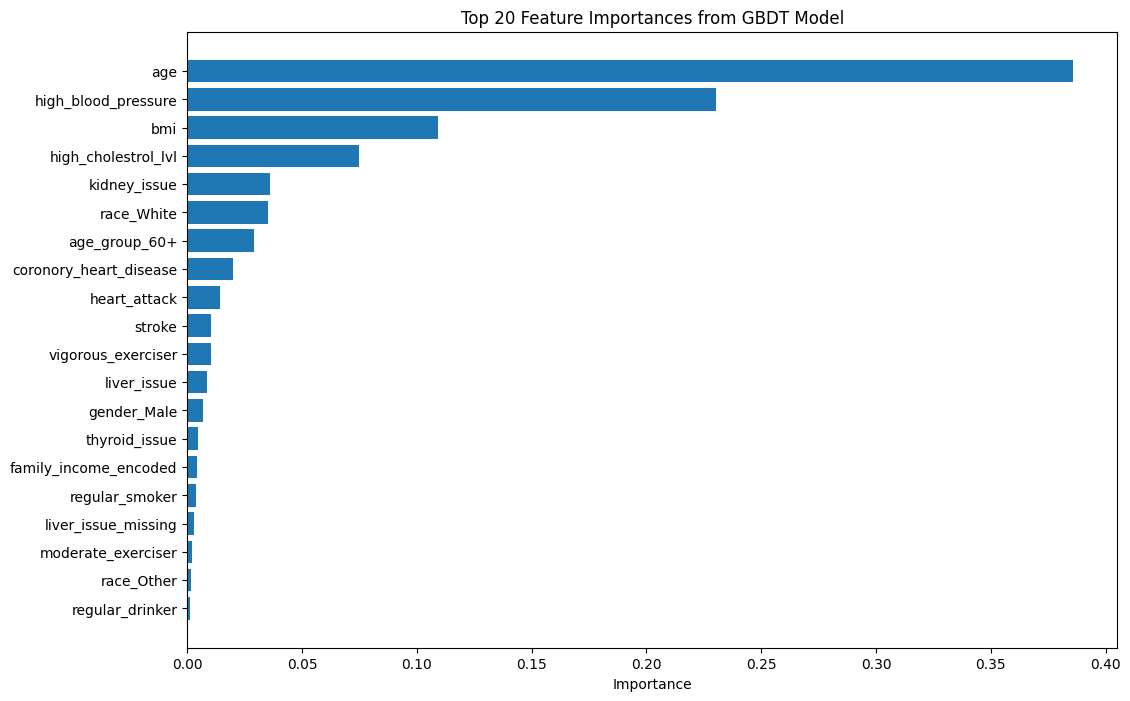

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Plot the top 20 important features
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'].head(20), feature_importance_df['Importance'].head(20))
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances from GBDT Model')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. 初始化 SMOTE
# sampling_strategy='auto' 会将少数类增加到与多数类相同的数量
smote = SMOTE(random_state=42)

# 2. 仅对训练集进行重采样
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. 检查重采样后的比例
print(f"原始训练集标签比例: {Counter(y_train)}")
print(f"重采样后训练集标签比例: {Counter(y_train_res)}")

原始训练集标签比例: Counter({0: 34335, 1: 3194})
重采样后训练集标签比例: Counter({0: 34335, 1: 34335})


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# --- 逻辑回归 ---
print("--- Logistic Regression (After SMOTE) ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res) # 使用平衡后的数据
y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))

# --- 原生 GBDT ---
print("\n--- GBDT (After SMOTE) ---")
gbdt_model = GradientBoostingClassifier(random_state=42)
gbdt_model.fit(X_train_res, y_train_res) # 使用平衡后的数据
y_pred_gbdt = gbdt_model.predict(X_test)
print(classification_report(y_test, y_pred_gbdt))

--- Logistic Regression (After SMOTE) ---
              precision    recall  f1-score   support

         0.0       0.99      0.79      0.88      8644
         1.0       0.26      0.86      0.40       739

    accuracy                           0.79      9383
   macro avg       0.62      0.83      0.64      9383
weighted avg       0.93      0.79      0.84      9383


--- GBDT (After SMOTE) ---
              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      8644
         1.0       0.34      0.59      0.43       739

    accuracy                           0.88      9383
   macro avg       0.65      0.75      0.68      9383
weighted avg       0.91      0.88      0.89      9383



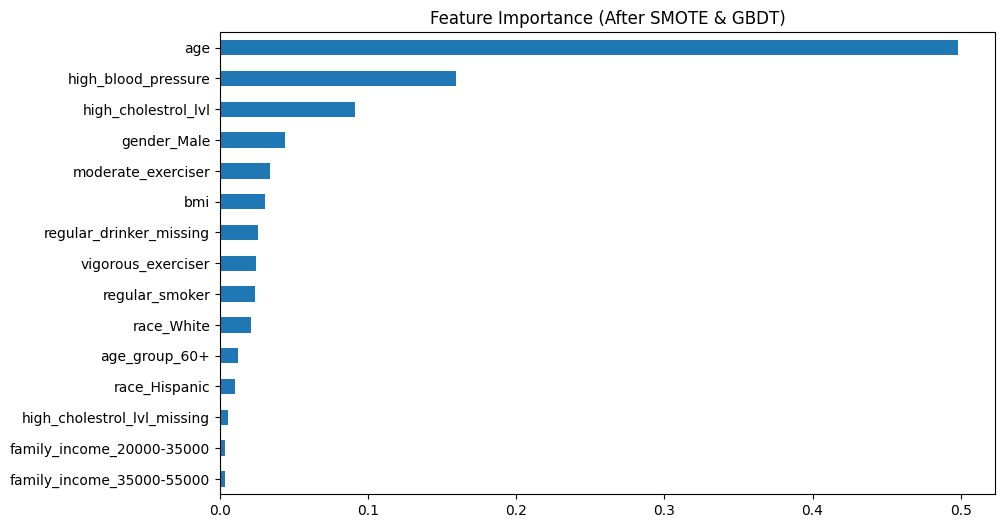

In [ ]:
# 基于平衡后数据训练的模型提取重要性
importances = gbdt_model.feature_importances_
feature_names = X.columns # 确保 X 是 one-hot 编码后的特征名

# 组合并排序
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 画图
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh')
plt.title('Feature Importance (After SMOTE & GBDT)')
plt.gca().invert_yaxis()
plt.show()

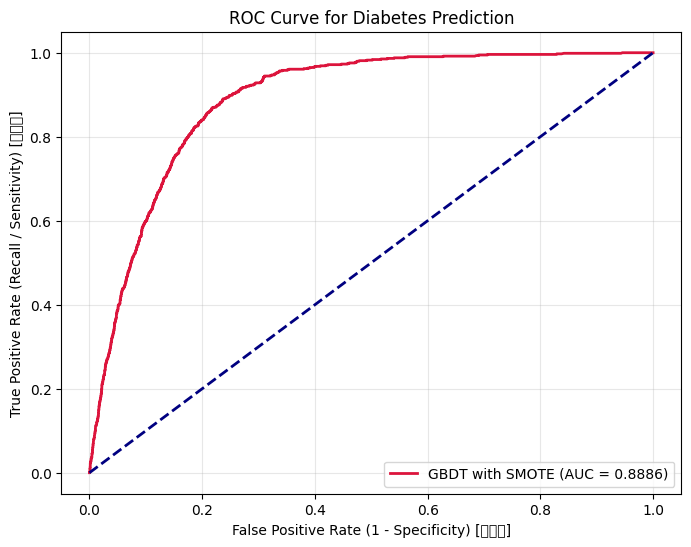

In [ ]:
# 计算 AUC 并绘制 ROC 曲线
auc_score = roc_auc_score(y_test, y_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GBDT with SMOTE (AUC = {auc_score:.4f})', color='crimson', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 对角线：随机瞎猜的基准线
plt.xlabel('False Positive Rate (1 - Specificity) [误诊率]')
plt.ylabel('True Positive Rate (Recall / Sensitivity) [敏感度]')
plt.title('ROC Curve for Diabetes Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

# 1. 初始化你的模型
# 这里以 GBDT 为例，你可以随时把它换成 LogisticRegression() 等其他模型
cv_model = GradientBoostingClassifier(random_state=42)

# 2. 设置交叉验证策略
# StratifiedKFold 保证了每次切分时，得病和没病的人数比例是一致的
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. 执行交叉验证
# 假设你想看的是模型抓取病人的能力，所以 scoring 设置为 'recall'
# 如果你想看准确率，可以改成 scoring='accuracy'
print("正在进行 5 折交叉验证，请稍候...")
scores = cross_val_score(
    cv_model,
    X_train_res,    # 请确保这里传入的是你 SMOTE 之后的训练集特征
    y_train_res,    # 对应 SMOTE 之后的训练集标签
    cv=cv_strategy,
    scoring='recall'
)

# 4. 输出结果
print(f"\n✅ 5次验证的独立得分: {scores}")
print(f"🎯 平均 Recall 得分: {scores.mean():.4f}")
print(f"📉 得分标准差 (波动越小越稳定): {scores.std():.4f}")

正在进行 5 折交叉验证，请稍候...

✅ 5次验证的独立得分: [0.93228484 0.93330421 0.9314111  0.93403233 0.93694481]
🎯 平均 Recall 得分: 0.9336
📉 得分标准差 (波动越小越稳定): 0.0019


In [ ]:
from xgboost import XGBClassifier

# 初始化 XGBoost
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 初步训练看一眼结果
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test)
print("\n--- Initial XGBoost Result ---")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [23:41:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- Initial XGBoost Result ---
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95      8644
         1.0       0.39      0.30      0.34       739

    accuracy                           0.91      9383
   macro avg       0.66      0.63      0.64      9383
weighted avg       0.90      0.91      0.90      9383



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'n_estimators': [100]
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

AttributeError: 'super' object has no attribute '__sklearn_tags__'